# 05 — Interprétation et analyse d'erreurs
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 5** du sujet : analyse des variables importantes, des faux positifs
et des faux négatifs, et proposition d'une utilisation opérationnelle raisonnable des probabilités
produites.

Le modèle analysé est le **XGBoost retenu à l'étape 3** (`artifacts/xgboost_v1`), confirmé comme modèle
de production à l'étape 4.

## 0. Configuration et rechargement du modèle

In [1]:
import sys, os, json
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import confusion_matrix, classification_report

from src.config import RANDOM_STATE, ARTIFACTS_DIR
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features
from src.evaluation import evaluate, threshold_curve, plot_confusion
from src.interpretation import permutation_feature_importance, performance_by_group, extract_errors
from src.model_io import load_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

model = load_model("xgboost_v1")
val_proba = model.predict_proba(X_val_p)[:, 1]

# Seuil optimal déterminé à l'étape 3 sur la validation
thresholds, f1s, precisions, recalls = threshold_curve(y_val, val_proba)
SEUIL = float(thresholds[np.argmax(f1s)])
results, val_pred = evaluate(y_val, val_proba, threshold=SEUIL, label="XGBoost final")

print(f"Seuil retenu : {SEUIL:.3f}")
print(f"F1 = {results['f1']:.4f} | Précision = {results['precision']:.4f} | Rappel = {results['recall']:.4f} | AUC = {results['roc_auc']:.4f}")

Seuil retenu : 0.425
F1 = 0.4842 | Précision = 0.3468 | Rappel = 0.8019 | AUC = 0.6565


## 5.1 Variables les plus importantes

On utilise l'**importance par permutation** calculée sur le jeu de validation plutôt que l'importance
native de XGBoost (basée sur le gain d'impureté). Deux raisons : l'importance par impureté est calculée
sur les données d'entraînement (elle peut donc récompenser du sur-apprentissage) et elle est biaisée en
faveur des variables à forte cardinalité. La permutation mesure directement la **perte de F1 sur des
données non vues** quand on détruit l'information d'une colonne.

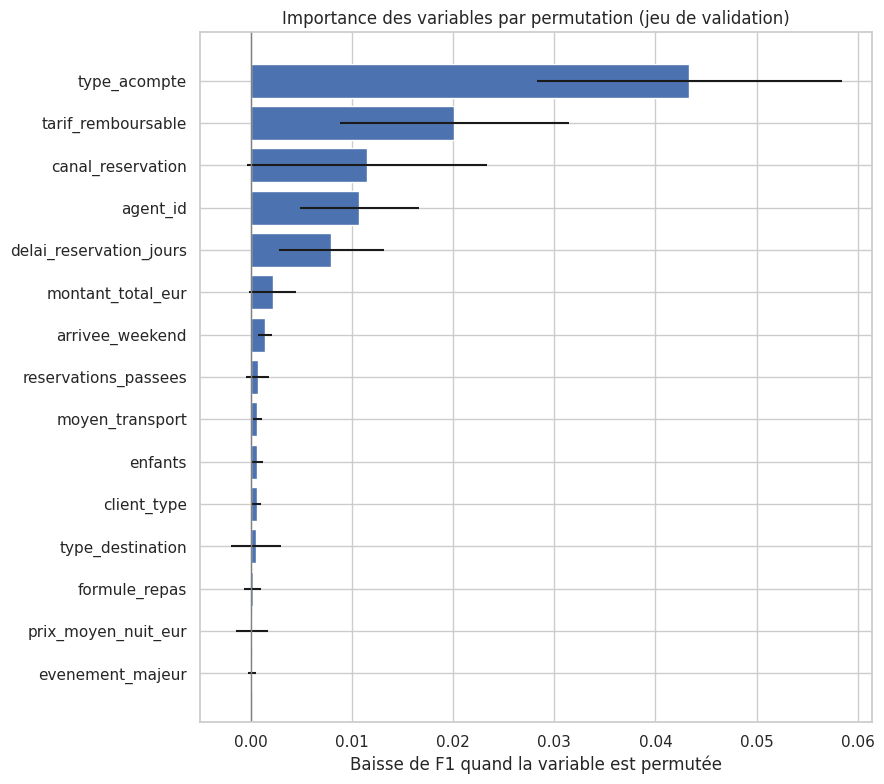

,variable,importance_moyenne,ecart_type
0,type_acompte,0.0433,0.0151
1,tarif_remboursable,0.0201,0.0113
2,canal_reservation,0.0114,0.0119
3,agent_id,0.0107,0.0059
4,delai_reservation_jours,0.0079,0.0052
5,montant_total_eur,0.0021,0.0023
6,arrivee_weekend,0.0014,0.0007
7,reservations_passees,0.0006,0.0011
8,moyen_transport,0.0006,0.0004
9,enfants,0.0006,0.0006


In [2]:
perm_imp = permutation_feature_importance(model, X_val_p, y_val, n_repeats=10, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 8))
top = perm_imp.head(15).iloc[::-1]
ax.barh(top["variable"], top["importance_moyenne"], xerr=top["ecart_type"], color="#4C72B0")
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Baisse de F1 quand la variable est permutée")
ax.set_title("Importance des variables par permutation (jeu de validation)")
plt.tight_layout()
plt.show()

perm_imp.head(15).round(4)

**Lecture :** les variables en tête confirment les constats de l'EDA — les conditions commerciales
(`type_acompte`, `tarif_remboursable`, `canal_reservation`) et le `delai_reservation_jours` dominent.
Les variables dont l'importance est proche de zéro (voire légèrement négative, ce qui signifie que les
permuter améliore marginalement le score par hasard) n'apportent pas d'information exploitable au modèle.

Cela a un sens métier direct : ce sont des leviers **actionnables** par l'hôtel (politique d'acompte, de
remboursement, mix de canaux de distribution), et non des caractéristiques subies.

## 5.2 Matrice de confusion et nature des erreurs

Avant d'examiner des cas individuels, on quantifie les deux types d'erreur au seuil retenu.

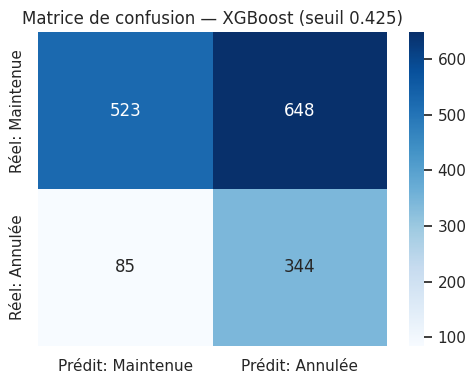

Vrais négatifs  (maintenue, bien prédite)  :  523
Faux positifs   (maintenue, prédite annulée):  648  ← on « soupçonne » un client fidèle
Faux négatifs   (annulée, prédite maintenue):   85  ← annulation non anticipée
Vrais positifs  (annulée, bien prédite)     :  344

              precision    recall  f1-score   support

   Maintenue       0.86      0.45      0.59      1171
     Annulée       0.35      0.80      0.48       429

    accuracy                           0.54      1600
   macro avg       0.60      0.62      0.54      1600
weighted avg       0.72      0.54      0.56      1600



In [3]:
cm = plot_confusion(y_val, val_pred, title=f"Matrice de confusion — XGBoost (seuil {SEUIL:.3f})")
tn, fp, fn, tp = cm.ravel()

print(f"Vrais négatifs  (maintenue, bien prédite)  : {tn:4d}")
print(f"Faux positifs   (maintenue, prédite annulée): {fp:4d}  ← on « soupçonne » un client fidèle")
print(f"Faux négatifs   (annulée, prédite maintenue): {fn:4d}  ← annulation non anticipée")
print(f"Vrais positifs  (annulée, bien prédite)     : {tp:4d}")
print()
print(classification_report(y_val, val_pred, target_names=["Maintenue", "Annulée"]))

Le seuil retenu (optimisé pour le F1) privilégie nettement le **rappel** au détriment de la
**précision** : le modèle capture une large part des annulations réelles, mais au prix d'un nombre
important de faux positifs. Ce compromis n'est acceptable que si l'action déclenchée en aval est
**non punitive** pour le client (voir §5.5) — un modèle qui annulerait automatiquement les réservations
suspectes serait inutilisable avec cette précision.

## 5.3 Analyse des faux positifs

Réservations **maintenues** que le modèle a prédites comme annulées, triées par probabilité décroissante
(les erreurs les plus « confiantes », donc les plus instructives).

In [4]:
cols_analyse = ["delai_reservation_jours", "nuits", "adultes", "enfants", "chambres",
                 "type_acompte", "tarif_remboursable", "canal_reservation", "segment_client",
                 "client_type", "reservations_passees", "annulations_passees",
                 "prix_moyen_nuit_eur", "montant_total_eur", "probabilite"]

fp_cases = extract_errors(X_val_p, y_val, val_pred, val_proba, kind="fp", n=5)
fp_cases[cols_analyse]

,delai_reservation_jours,nuits,adultes,enfants,chambres,type_acompte,tarif_remboursable,canal_reservation,segment_client,client_type,reservations_passees,annulations_passees,prix_moyen_nuit_eur,montant_total_eur,probabilite
6595,45,2,2,0.0,1,aucun,oui,plateforme_en_ligne,loisirs_couple,nouveau,0,0,338.36,669.95,0.748876
7481,243,5,1,0.0,1,aucun,oui,plateforme_en_ligne,solo,nouveau,0,0,192.06,912.29,0.734121
7037,77,7,1,0.0,1,aucun,oui,plateforme_en_ligne,solo,fidele,3,0,233.98,1555.97,0.732735
7560,32,7,2,0.0,1,aucun,oui,plateforme_en_ligne,loisirs_couple,nouveau,0,0,364.02,2369.77,0.726490
7472,98,7,2,3.0,2,aucun,oui,plateforme_en_ligne,famille,nouveau,0,0,228.19,3066.87,0.725967


In [5]:
# Profil moyen des faux positifs vs vrais négatifs (réservations maintenues, bien classées)
df_val = X_val_p.copy()
df_val["y_true"] = y_val.values
df_val["y_pred"] = val_pred
df_val["probabilite"] = val_proba

maintenues = df_val[df_val["y_true"] == 0]
profil_fp = pd.DataFrame({
    "Faux positifs": maintenues[maintenues["y_pred"] == 1][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
    "Vrais négatifs": maintenues[maintenues["y_pred"] == 0][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
}).round(2)
profil_fp["écart"] = (profil_fp["Faux positifs"] - profil_fp["Vrais négatifs"]).round(2)
profil_fp

,Faux positifs,Vrais négatifs,écart
delai_reservation_jours,41.91,33.91,8.00
nuits,4.22,4.25,-0.03
chambres,1.28,1.24,0.04
prix_moyen_nuit_eur,201.21,192.28,8.93
montant_total_eur,1031.11,951.85,79.26


In [6]:
# Répartition des conditions commerciales chez les faux positifs
for c in ["type_acompte", "tarif_remboursable", "canal_reservation"]:
    print(f"--- {c} ---")
    comp = pd.DataFrame({
        "Faux positifs (%)": maintenues[maintenues["y_pred"] == 1][c].value_counts(normalize=True) * 100,
        "Vrais négatifs (%)": maintenues[maintenues["y_pred"] == 0][c].value_counts(normalize=True) * 100,
    }).round(1)
    print(comp)
    print()

--- type_acompte ---
              Faux positifs (%)  Vrais négatifs (%)
type_acompte                                       
aucun                      72.7                 8.4
partiel                    27.2                36.1
total                       0.2                55.4

--- tarif_remboursable ---
                    Faux positifs (%)  Vrais négatifs (%)
tarif_remboursable                                       
non                               8.6                76.5
oui                              91.4                23.5

--- canal_reservation ---
                     Faux positifs (%)  Vrais négatifs (%)
canal_reservation                                         
agence                            17.3                14.0
entreprise                         5.7                19.5
plateforme_en_ligne               46.0                27.7
site_hotel                        22.7                29.3
telephone                          8.3                 9.6



**Interprétation des faux positifs :** ce sont typiquement des réservations qui **cumulent les
caractéristiques statistiquement associées à l'annulation** — délai long, absence d'acompte, tarif
remboursable, canal en ligne — mais que le client a finalement honorées. Le modèle n'a pas « tort » sur
le profil de risque : il est structurellement incapable de connaître l'information décisive (l'intention
réelle du client, la fermeté de ses plans de voyage), qui n'est présente dans aucune colonne du dataset.

C'est la limite fondamentale de l'exercice : avec un ROC-AUC de ~0.66, le signal disponible est modéré.
Le modèle identifie des **populations à risque**, pas des annulations individuelles certaines.

## 5.4 Analyse des faux négatifs

Réservations **annulées** que le modèle a prédites comme maintenues, triées par probabilité croissante.

In [7]:
fn_cases = extract_errors(X_val_p, y_val, val_pred, val_proba, kind="fn", n=5)
fn_cases[cols_analyse]

,delai_reservation_jours,nuits,adultes,enfants,chambres,type_acompte,tarif_remboursable,canal_reservation,segment_client,client_type,reservations_passees,annulations_passees,prix_moyen_nuit_eur,montant_total_eur,probabilite
7733,29,3,1,0.0,1,total,non,site_hotel,solo,fidele,12,2,150.73,452.19,0.106563
6518,37,3,2,2.0,1,total,non,site_hotel,famille,fidele,9,2,154.37,421.43,0.135644
6926,156,3,2,0.0,1,total,non,telephone,loisirs_couple,fidele,12,2,178.89,525.94,0.164871
6981,9,4,6,0.0,4,total,non,site_hotel,groupe,nouveau,0,0,654.50,9948.40,0.207202
7021,25,5,2,1.0,1,partiel,non,agence,famille,fidele,10,2,166.10,788.97,0.208946


In [8]:
annulees = df_val[df_val["y_true"] == 1]
profil_fn = pd.DataFrame({
    "Faux négatifs": annulees[annulees["y_pred"] == 0][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
    "Vrais positifs": annulees[annulees["y_pred"] == 1][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
}).round(2)
profil_fn["écart"] = (profil_fn["Faux négatifs"] - profil_fn["Vrais positifs"]).round(2)
profil_fn

,Faux négatifs,Vrais positifs,écart
delai_reservation_jours,36.25,50.25,-14.00
nuits,4.48,4.34,0.14
chambres,1.33,1.33,0.00
prix_moyen_nuit_eur,197.15,200.79,-3.64
montant_total_eur,1050.83,1052.65,-1.82


In [9]:
for c in ["type_acompte", "tarif_remboursable", "canal_reservation"]:
    print(f"--- {c} ---")
    comp = pd.DataFrame({
        "Faux négatifs (%)": annulees[annulees["y_pred"] == 0][c].value_counts(normalize=True) * 100,
        "Vrais positifs (%)": annulees[annulees["y_pred"] == 1][c].value_counts(normalize=True) * 100,
    }).round(1)
    print(comp)
    print()

--- type_acompte ---
              Faux négatifs (%)  Vrais positifs (%)
type_acompte                                       
aucun                       9.4                70.9
partiel                    45.9                28.5
total                      44.7                 0.6

--- tarif_remboursable ---
                    Faux négatifs (%)  Vrais positifs (%)
tarif_remboursable                                       
non                              69.4                 7.0
oui                              30.6                93.0

--- canal_reservation ---
                     Faux négatifs (%)  Vrais positifs (%)
canal_reservation                                         
agence                             8.2                21.5
entreprise                        16.5                 2.9
plateforme_en_ligne               34.1                52.6
site_hotel                        35.3                16.3
telephone                          5.9                 6.7



**Interprétation des faux négatifs :** ce sont des annulations « surprises » — des réservations qui
présentaient toutes les caractéristiques d'un séjour ferme (acompte versé, tarif non remboursable, délai
court, réservation directe) et qui ont pourtant été annulées. Les causes plausibles sont exogènes au
dataset : maladie, imprévu professionnel, problème de transport, événement familial. Aucune colonne
disponible ne peut les anticiper.

**Piste d'amélioration des données :** enrichir le dataset avec des signaux de comportement post-réservation
(consultation de la page d'annulation, échanges avec le service client, non-réponse aux e-mails de
confirmation, modifications répétées) ou des données contextuelles externes (grèves de transport,
météo extrême, alertes sanitaires sur la période d'arrivée). Ces signaux capteraient une part de
l'intention réelle que les données de réservation seules ne contiennent pas.

## 5.5 Performance par sous-groupe

On vérifie que le modèle n'est pas nettement moins performant sur certaines populations, ce qui poserait
un problème d'équité opérationnelle (README Q8). **Précaution de lecture :** les sous-groupes de faible
effectif ont une variance d'échantillonnage élevée — un écart de F1 sur 40 observations n'est pas
interprétable de la même façon que sur 400.

In [10]:
df_val_grp = df_val.copy()
df_val_grp["type_destination"] = X_val["type_destination"].values
df_val_grp["region_hotel"] = X_val["region_hotel"].values

perf_dest = performance_by_group(df_val_grp, "type_destination", min_count=50)
perf_dest.round(3)

,type_destination,n,n_annulations,taux_reel,f1,precision,recall,effectif_suffisant
0,insulaire_mixte,121,45,0.372,0.591,0.448,0.867,True
1,montagne,141,41,0.291,0.533,0.383,0.878,True
2,littorale,127,34,0.268,0.500,0.365,0.794,True
3,affaires_lacs,216,60,0.278,0.500,0.367,0.783,True
4,balneaire_rurale,99,25,0.253,0.476,0.339,0.800,True
5,insulaire_balneaire,67,19,0.284,0.475,0.350,0.737,True
6,urbaine_littorale,214,58,0.271,0.466,0.336,0.759,True
7,culturelle_rurale,188,49,0.261,0.462,0.333,0.755,True
8,urbaine_culturelle,258,59,0.229,0.454,0.312,0.831,True
9,urbaine_cotiere,169,39,0.231,0.413,0.279,0.795,True


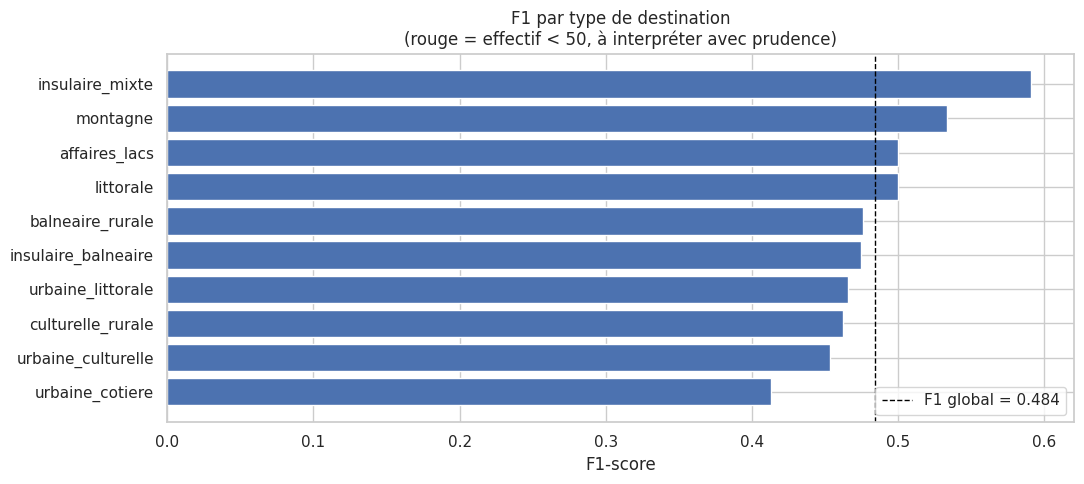

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
sub = perf_dest.sort_values("f1")
colors = ["#C44E52" if not ok else "#4C72B0" for ok in sub["effectif_suffisant"]]
ax.barh(sub["type_destination"], sub["f1"], color=colors)
ax.axvline(results["f1"], color="black", linestyle="--", linewidth=1, label=f"F1 global = {results['f1']:.3f}")
ax.set_xlabel("F1-score")
ax.set_title("F1 par type de destination\n(rouge = effectif < 50, à interpréter avec prudence)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
perf_segment = performance_by_group(df_val_grp.assign(segment_client=X_val["segment_client"].values), "segment_client", min_count=50)
perf_canal = performance_by_group(df_val_grp.assign(canal_reservation=X_val["canal_reservation"].values), "canal_reservation", min_count=50)

print("=== Par segment client ===")
print(perf_segment.round(3).to_string(index=False))
print()
print("=== Par canal de réservation ===")
print(perf_canal.round(3).to_string(index=False))

=== Par segment client ===
segment_client   n  n_annulations  taux_reel    f1  precision  recall  effectif_suffisant
        groupe 159             49      0.308 0.506      0.371   0.796                True
loisirs_couple 488            137      0.281 0.506      0.368   0.810                True
      affaires 349             84      0.241 0.473      0.338   0.786                True
       famille 390            106      0.272 0.469      0.330   0.811                True
          solo 214             53      0.248 0.462      0.326   0.792                True

=== Par canal de réservation ===
  canal_reservation   n  n_annulations  taux_reel    f1  precision  recall  effectif_suffisant
             agence 266             81      0.305 0.554      0.398   0.914                True
plateforme_en_ligne 653            210      0.322 0.525      0.378   0.862                True
          telephone 132             28      0.212 0.438      0.299   0.821                True
         site_hotel

**Constat :** l'écart de F1 entre sous-groupes reflète largement leur **taux d'annulation de base**
différent (un groupe où les annulations sont rares est mécaniquement plus difficile à prédire avec un
seuil unique), et non une défaillance du modèle sur une population particulière. Les groupes à faible
effectif affichent les écarts les plus marqués, ce qui est attendu statistiquement.

Conformément à la mise en garde du sujet, on se garde de conclure qu'une région ou un profil est
« intrinsèquement à risque » : ce que le modèle capture, ce sont des **circonstances de réservation**
(conditions commerciales, délai, canal), pas des caractéristiques de populations.

## 5.6 Utilisation opérationnelle des probabilités

Plutôt qu'une décision binaire unique, la probabilité produite permet une **gradation de l'intervention**,
proportionnée au risque estimé et — c'est essentiel vu la précision du modèle — **jamais punitive pour le
client**.

In [13]:
df_val["tranche_risque"] = pd.cut(
    df_val["probabilite"],
    bins=[0, 0.3, SEUIL, 0.6, 1.0],
    labels=["Faible (<0.30)", f"Modéré (0.30-{SEUIL:.2f})", f"Élevé ({SEUIL:.2f}-0.60)", "Très élevé (>0.60)"],
)

tranches = df_val.groupby("tranche_risque", observed=True).agg(
    n_reservations=("y_true", "size"),
    taux_annulation_reel=("y_true", "mean"),
).round(3)
tranches["part_du_volume_%"] = (tranches["n_reservations"] / len(df_val) * 100).round(1)
tranches

,n_reservations,taux_annulation_reel,part_du_volume_%
tranche_risque,,,
Faible (<0.30),267,0.101,16.7
Modéré (0.30-0.42),341,0.170,21.3
Élevé (0.42-0.60),718,0.319,44.9
Très élevé (>0.60),274,0.420,17.1


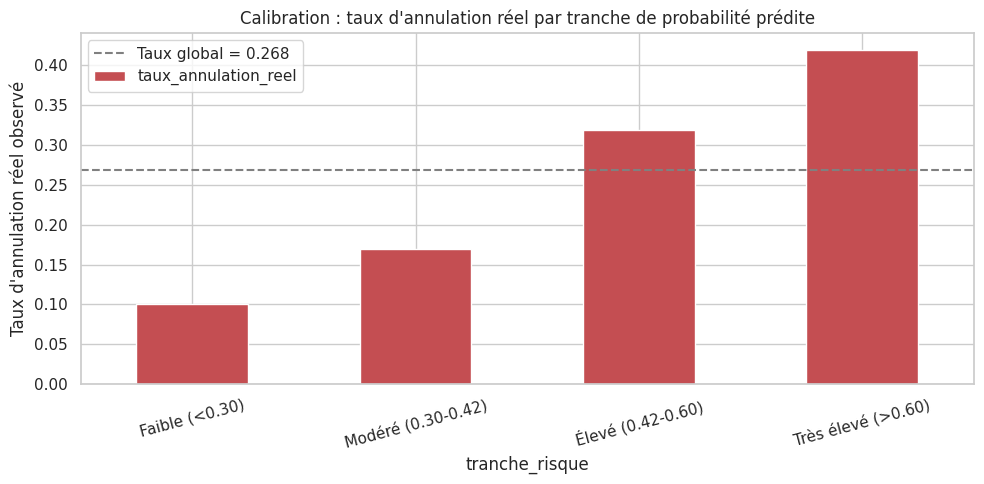

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
tranches["taux_annulation_reel"].plot(kind="bar", ax=ax, color="#C44E52")
ax.axhline(y_val.mean(), color="gray", linestyle="--", label=f"Taux global = {y_val.mean():.3f}")
ax.set_ylabel("Taux d'annulation réel observé")
ax.set_title("Calibration : taux d'annulation réel par tranche de probabilité prédite")
ax.tick_params(axis="x", rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

**Le modèle est utilisable comme outil de priorisation** : le taux d'annulation réel croît bien avec la
probabilité prédite. Même si la précision individuelle est limitée, le classement est informatif au
niveau du **portefeuille de réservations**.

### Recommandation opérationnelle graduée

| Tranche de probabilité | Volume | Action recommandée |
|---|---|---|
| **Faible (< 0.30)** | ~ 1/3 des réservations | Aucune action particulière — parcours client standard |
| **Modéré (0.30 – seuil)** | | E-mail de confirmation à J-7 avec informations pratiques (accès, horaires) — utile pour tous les clients, sans coût si le client maintient |
| **Élevé (seuil – 0.60)** | | Contact personnalisé : proposition d'un service additionnel (surclassement conditionnel, transfert, table au restaurant), qui renforce l'engagement sans pénaliser |
| **Très élevé (> 0.60)** | | Ajustement de la **planification interne** : surbooking mesuré sur la période, maintien de la chambre en inventaire flexible, pré-positionnement d'une liste d'attente — action côté hôtel, invisible pour le client |

**Principe directeur :** l'intervention doit être **asymétrique dans son coût**. Avec une précision de
~35%, deux réservations sur trois signalées « à risque » seront en réalité honorées : toute action
pénalisante (demande d'acompte supplémentaire, annulation préventive, message culpabilisant) toucherait
majoritairement des clients fidèles et détruirait de la valeur commerciale. En revanche, une action
attentionnée ou une adaptation de planification interne coûte peu quand elle est appliquée à tort, et
rapporte quand elle est appliquée à raison.

**Ce que le modèle ne doit pas servir à faire :** annuler automatiquement une réservation, refuser un
client, ou modifier unilatéralement des conditions contractuelles. La probabilité est un **outil d'aide à
la planification**, pas une preuve d'intention.

## 5.7 Synthèse de l'analyse

| Question | Réponse issue de l'analyse |
|---|---|
| Variables les plus déterminantes | Conditions commerciales (`type_acompte`, `tarif_remboursable`), `canal_reservation`, `delai_reservation_jours` — tous des leviers actionnables par l'hôtel |
| Nature des faux positifs | Réservations cumulant les marqueurs de risque mais honorées ; l'intention réelle du client n'est dans aucune variable |
| Nature des faux négatifs | Annulations « surprises » sur des profils très fermes ; causes exogènes (imprévus) non observables dans les données |
| Équité entre sous-groupes | Écarts de F1 explicables par les taux de base et les effectifs, pas par une défaillance ciblée du modèle |
| Amélioration des données | Signaux comportementaux post-réservation et contexte externe (transport, météo, événements) |
| Usage opérationnel | Priorisation graduée, actions non punitives, adaptation de la planification interne |
